# 📊 Visualisations IRC - Index de Résilience Civilisationnelle

**Date**: 28 février 2026  
**Base de données**: worlddatavision  
**Objectif**: Visualiser la couverture et la densité des indicateurs IRC

Ce notebook présente des visualisations clés pour analyser l'état des données IRC.

In [31]:
# Import des bibliothèques
import psycopg2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration des graphiques
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 10

# Connexion à la base de données
conn = psycopg2.connect(
    dbname="worlddatavision",
    user="elias",
    password="MaBaseDeDonnee",
    host="localhost",
    port="5432"
)

print("✅ Connexion établie à la base de données worlddatavision")

✅ Connexion établie à la base de données worlddatavision


## 1️⃣ Couverture Temporelle des Indicateurs IRC

Visualisation de la période de couverture de chaque indicateur (diagramme de Gantt).

In [32]:
# Requête pour obtenir les années min/max de chaque indicateur
query_temporal = """
SELECT 
    i.code,
    i.name,
    i.category_id,
    MIN(iv.year) as first_year,
    MAX(iv.year) as last_year,
    COUNT(DISTINCT iv.country_id) as country_count,
    COUNT(*) as total_values
FROM indicator i
LEFT JOIN indicator_value iv ON i.id = iv.indicator_id
WHERE i.code != 'EN.ATM.CO2E.PC'
GROUP BY i.id, i.code, i.name, i.category_id
ORDER BY i.category_id, i.code;
"""

temporal_df = pd.read_sql(query_temporal, conn)

print(f"📊 {len(temporal_df)} indicateurs chargés")
print(f"📅 Période: {temporal_df['first_year'].min():.0f} - {temporal_df['last_year'].max():.0f}")

📊 75 indicateurs chargés
📅 Période: 1950 - 2025


/tmp/ipykernel_128171/577345799.py:18: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  temporal_df = pd.read_sql(query_temporal, conn)


/tmp/ipykernel_128171/2396524102.py:35: UserWarning: Glyph 128197 (\N{CALENDAR}) missing from current font.
  plt.tight_layout()
/home/elias/anaconda3/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 128197 (\N{CALENDAR}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


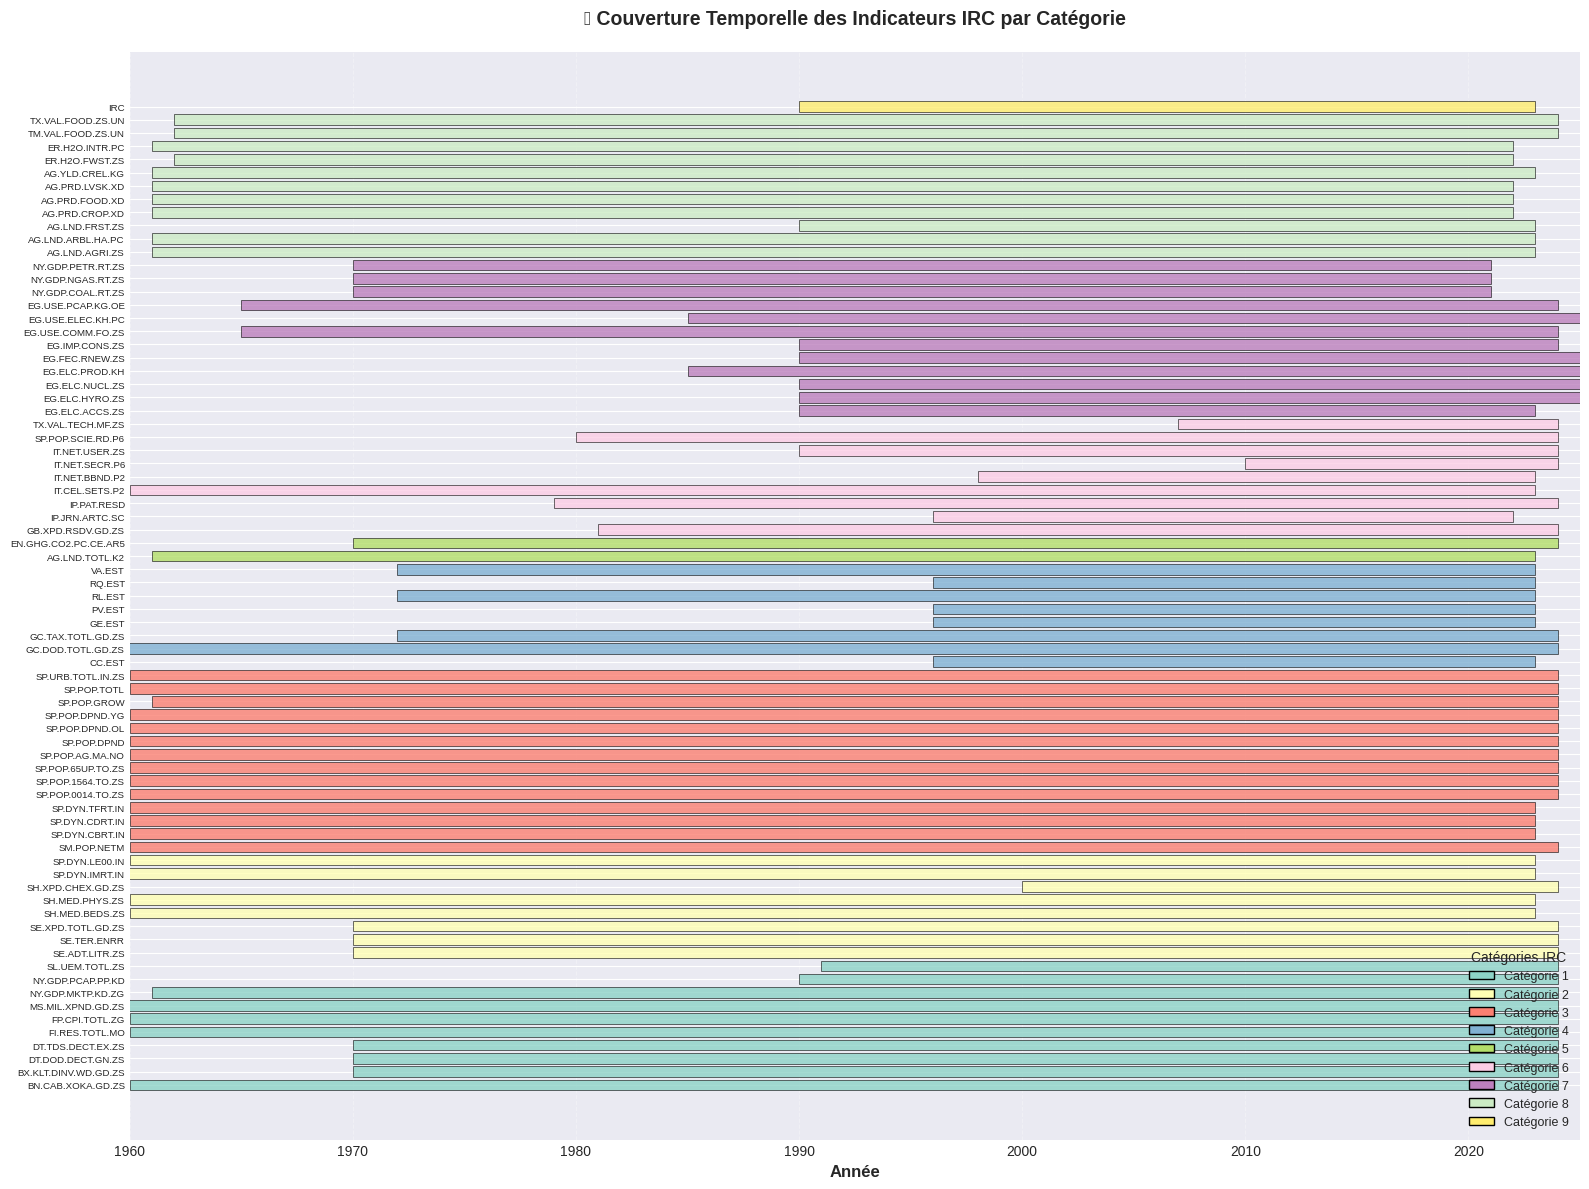


📊 Statistiques de couverture temporelle:
  • Année la plus ancienne: 1950
  • Année la plus récente: 2025
  • Durée moyenne de couverture: 51.5 ans
  • Nombre moyen de pays par indicateur: 199.7


In [33]:
# Diagramme de Gantt - Couverture temporelle
fig, ax = plt.subplots(figsize=(16, 12))

# Créer une palette de couleurs par catégorie
categories = temporal_df['category_id'].unique()
colors = plt.cm.Set3(np.linspace(0, 1, len(categories)))
color_map = dict(zip(sorted(categories), colors))

# Dessiner une barre pour chaque indicateur
for idx, row in temporal_df.iterrows():
    if pd.notna(row['first_year']) and pd.notna(row['last_year']):
        start = int(row['first_year'])
        end = int(row['last_year'])
        ax.barh(idx, end - start, left=start, height=0.8, 
                color=color_map[row['category_id']], 
                edgecolor='black', linewidth=0.5,
                alpha=0.8)

# Configuration des axes
ax.set_yticks(range(len(temporal_df)))
ax.set_yticklabels(temporal_df['code'], fontsize=7)
ax.set_xlabel('Année', fontsize=12, fontweight='bold')
ax.set_title('📅 Couverture Temporelle des Indicateurs IRC par Catégorie', 
             fontsize=14, fontweight='bold', pad=20)
ax.grid(axis='x', alpha=0.3, linestyle='--')
ax.set_xlim(1960, 2025)

# Légende
legend_elements = [plt.Rectangle((0,0),1,1, fc=color_map[cat], 
                                edgecolor='black', label=f'Catégorie {cat}') 
                   for cat in sorted(categories)]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9, 
         title='Catégories IRC', title_fontsize=10)

plt.tight_layout()
plt.show()

# Statistiques
print("\n📊 Statistiques de couverture temporelle:")
print(f"  • Année la plus ancienne: {temporal_df['first_year'].min():.0f}")
print(f"  • Année la plus récente: {temporal_df['last_year'].max():.0f}")
print(f"  • Durée moyenne de couverture: {(temporal_df['last_year'] - temporal_df['first_year']).mean():.1f} ans")
print(f"  • Nombre moyen de pays par indicateur: {temporal_df['country_count'].mean():.1f}")

## 2️⃣ Densité des Indicateurs par Nombre de Pays

Distribution du nombre de pays ayant des données pour chaque indicateur.

In [34]:
# Préparer les données pour la densité
density_df = temporal_df[['code', 'name', 'category_id', 'country_count', 'total_values']].copy()
density_df = density_df.sort_values('country_count', ascending=False)

print(f"\n📊 Distribution de la couverture pays:")
print(f"  • Indicateur le plus couvert: {density_df.iloc[0]['code']} ({density_df.iloc[0]['country_count']} pays)")
print(f"  • Indicateur le moins couvert: {density_df.iloc[-1]['code']} ({density_df.iloc[-1]['country_count']} pays)")
print(f"  • Moyenne: {density_df['country_count'].mean():.1f} pays par indicateur")
print(f"  • Médiane: {density_df['country_count'].median():.1f} pays par indicateur")


📊 Distribution de la couverture pays:
  • Indicateur le plus couvert: EG.FEC.RNEW.ZS (225 pays)
  • Indicateur le moins couvert: DT.TDS.DECT.EX.ZS (121 pays)
  • Moyenne: 199.7 pays par indicateur
  • Médiane: 206.0 pays par indicateur


/tmp/ipykernel_128171/352742948.py:40: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_128171/352742948.py:40: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from current font.
  plt.tight_layout()
/home/elias/anaconda3/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/home/elias/anaconda3/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


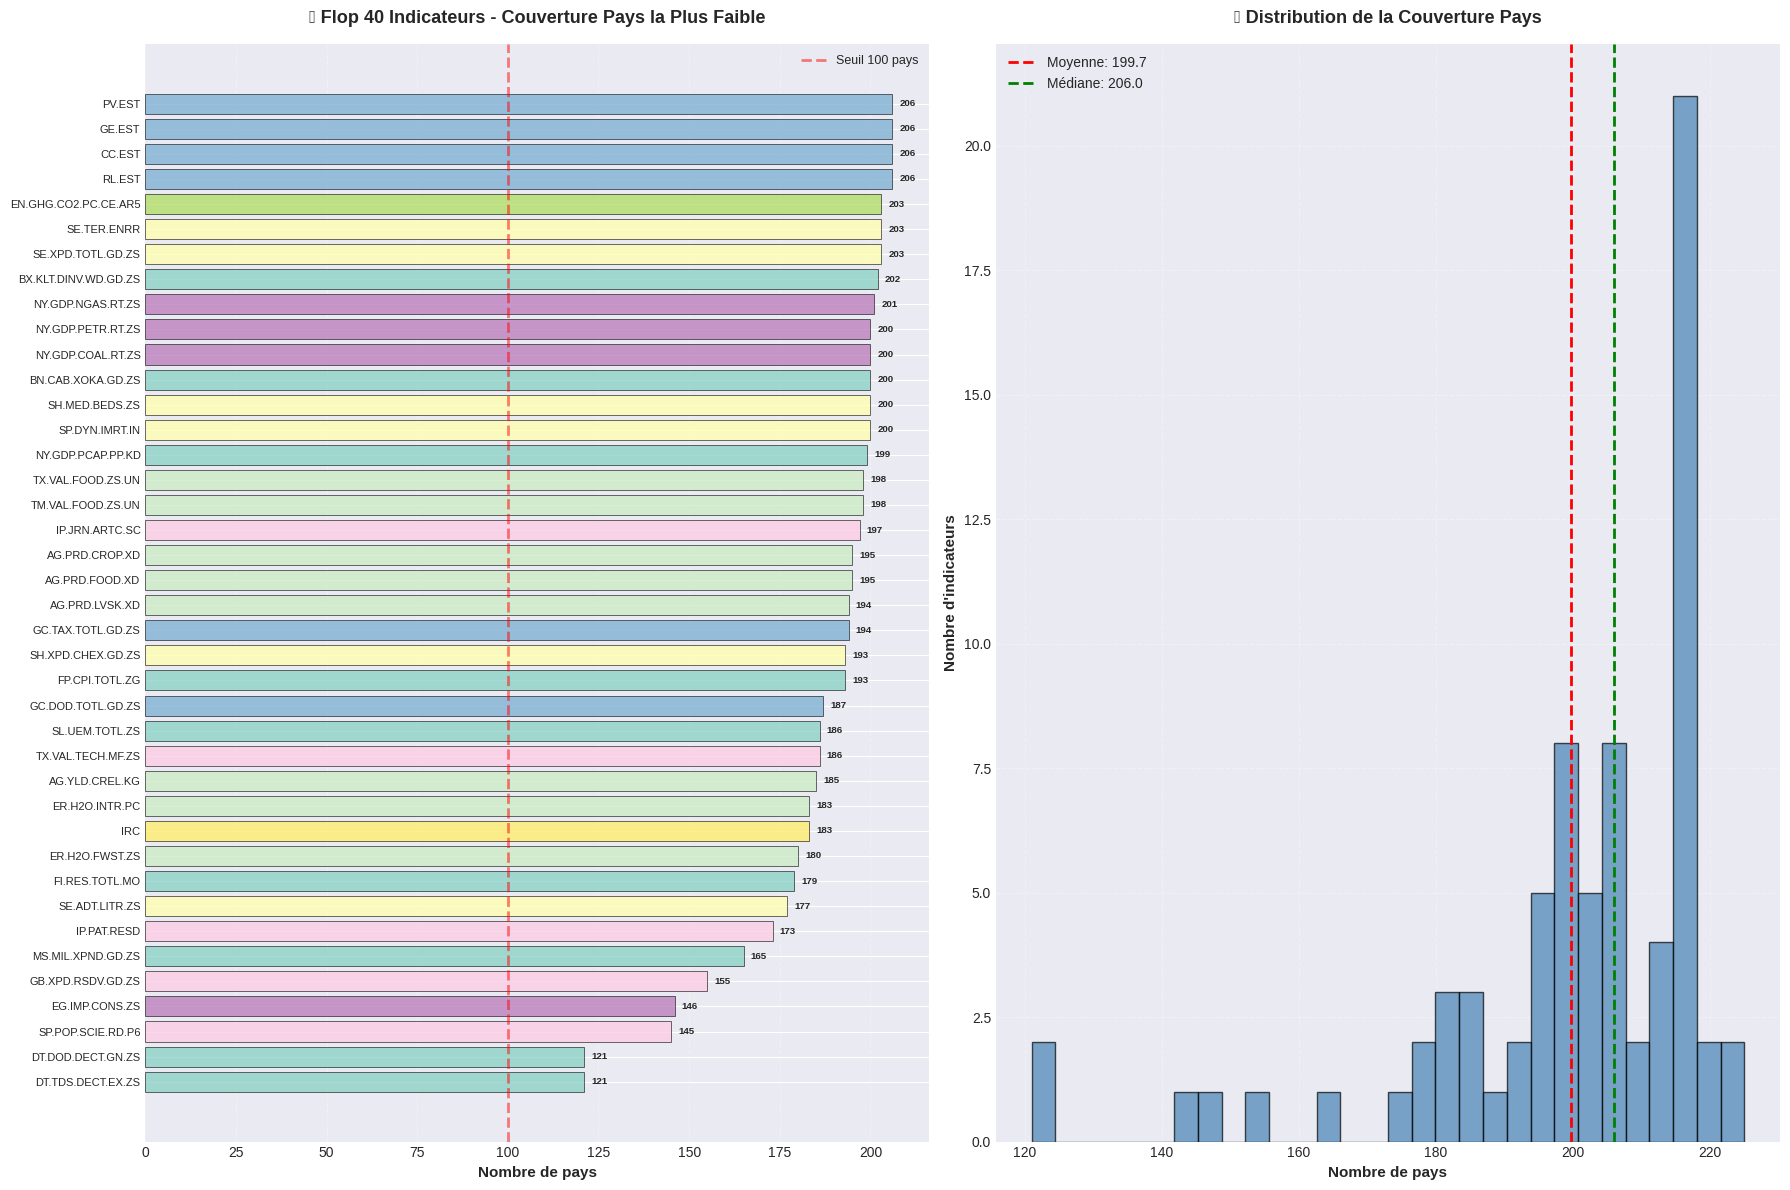

In [35]:
# Graphique 1: Barplot horizontal - Nombre de pays par indicateur
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 12))

# Graphique de gauche: Flop 40 indicateurs (les moins couverts)
flop_n = 40
flop_indicators = density_df.tail(flop_n).iloc[::-1]  # Inverser pour avoir le pire en haut

bars1 = ax1.barh(range(len(flop_indicators)), flop_indicators['country_count'],
                color=[color_map[cat] for cat in flop_indicators['category_id']],
                edgecolor='black', linewidth=0.5, alpha=0.8)

ax1.set_yticks(range(len(flop_indicators)))
ax1.set_yticklabels(flop_indicators['code'], fontsize=8)
ax1.set_xlabel('Nombre de pays', fontsize=11, fontweight='bold')
ax1.set_title(f'📉 Flop {flop_n} Indicateurs - Couverture Pays la Plus Faible', 
             fontsize=13, fontweight='bold', pad=15)
ax1.grid(axis='x', alpha=0.3, linestyle='--')
ax1.axvline(x=100, color='red', linestyle='--', linewidth=2, alpha=0.5, label='Seuil 100 pays')
ax1.legend(fontsize=9)

# Ajouter les valeurs sur les barres
for i, (idx, row) in enumerate(flop_indicators.iterrows()):
    ax1.text(row['country_count'] + 2, i, f"{row['country_count']:.0f}", 
            va='center', fontsize=7, fontweight='bold')

# Graphique de droite: Distribution (histogramme)
ax2.hist(density_df['country_count'], bins=30, edgecolor='black', 
        color='steelblue', alpha=0.7)
ax2.axvline(density_df['country_count'].mean(), color='red', 
           linestyle='--', linewidth=2, label=f"Moyenne: {density_df['country_count'].mean():.1f}")
ax2.axvline(density_df['country_count'].median(), color='green', 
           linestyle='--', linewidth=2, label=f"Médiane: {density_df['country_count'].median():.1f}")
ax2.set_xlabel('Nombre de pays', fontsize=11, fontweight='bold')
ax2.set_ylabel('Nombre d\'indicateurs', fontsize=11, fontweight='bold')
ax2.set_title('📊 Distribution de la Couverture Pays', 
             fontsize=13, fontweight='bold', pad=15)
ax2.grid(alpha=0.3, linestyle='--')
ax2.legend(fontsize=10)

plt.tight_layout()
plt.show()

## 3️⃣ Heatmap de Densité par Catégorie

Visualisation de la densité de couverture pour chaque catégorie IRC.

In [36]:
# Calculer les statistiques par catégorie
category_stats = density_df.groupby('category_id').agg({
    'country_count': ['count', 'mean', 'median', 'min', 'max'],
    'total_values': ['sum', 'mean']
}).round(1)

print("\n📊 Statistiques par catégorie IRC:")
print(category_stats)


📊 Statistiques par catégorie IRC:
            country_count                         total_values         
                    count   mean median  min  max          sum     mean
category_id                                                            
1                      10  177.9  189.5  121  213        75857   7585.7
2                       8  199.9  201.5  177  216        52505   6563.1
3                      14  216.0  216.0  216  216       195452  13960.9
4                       8  202.1  206.0  187  206        46160   5770.0
5                       2  209.0  209.0  203  215        23453  11726.5
6                       9  189.6  197.0  145  215        41340   4593.3
7                      12  208.2  215.5  146  225        91120   7593.3
8                      11  196.0  195.0  180  213       107062   9732.9
9                       1  183.0  183.0  183  183         4045   4045.0


/tmp/ipykernel_128171/326925256.py:48: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_128171/326925256.py:48: UserWarning: Glyph 127931 (\N{VIOLIN}) missing from current font.
  plt.tight_layout()
/home/elias/anaconda3/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/home/elias/anaconda3/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 127931 (\N{VIOLIN}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


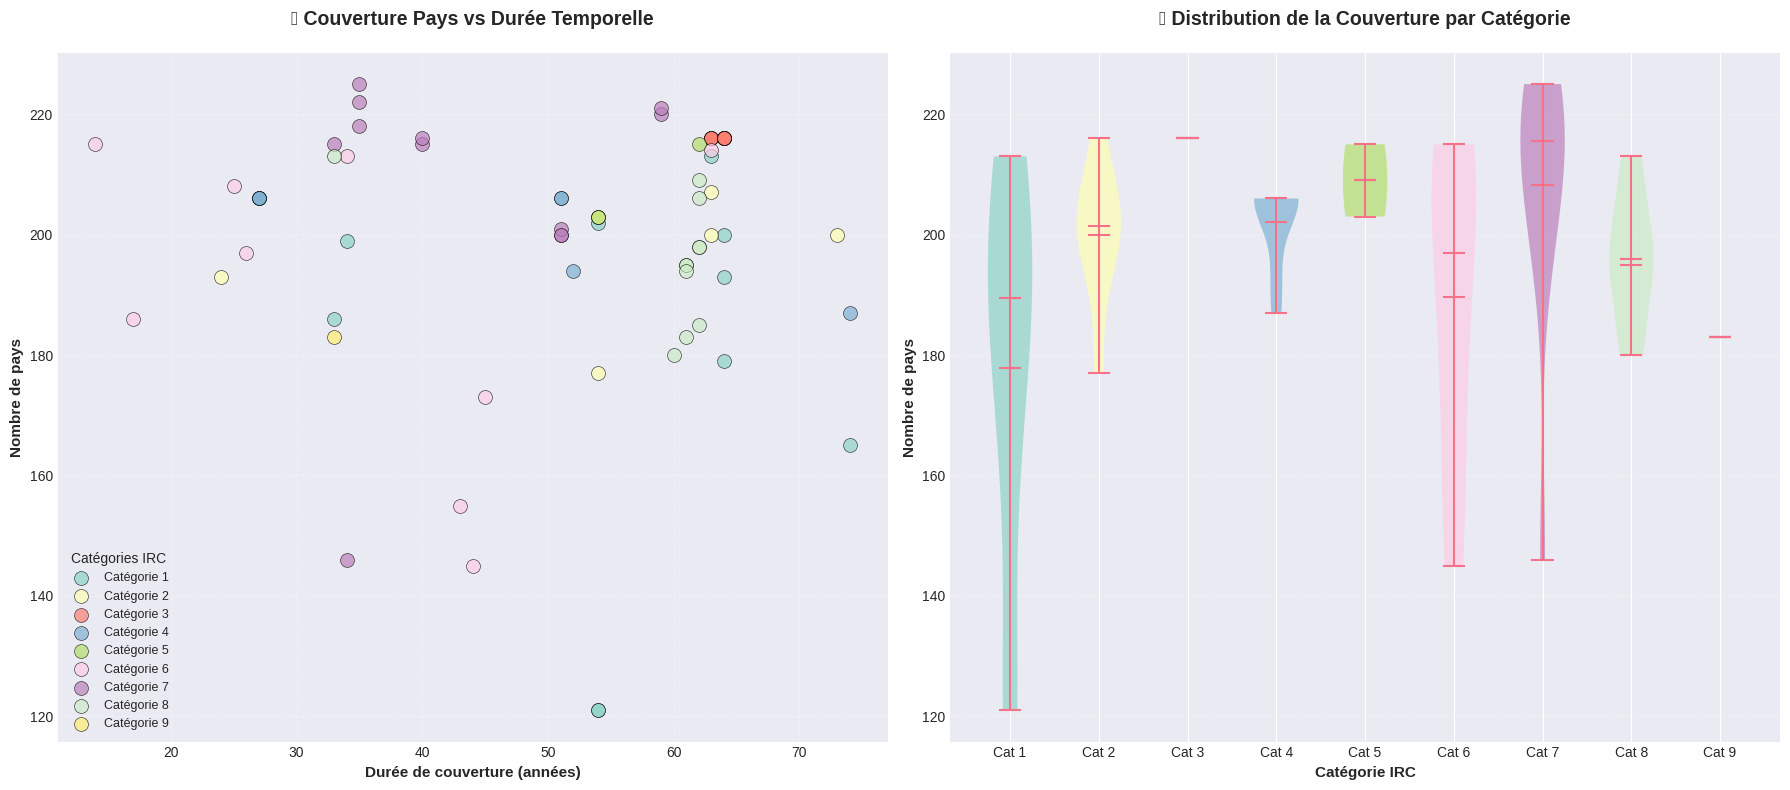

In [37]:
# Créer un scatter plot: Couverture Pays vs Durée Temporelle
temporal_df['duration'] = temporal_df['last_year'] - temporal_df['first_year']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

# Scatter plot: Couverture vs Durée par catégorie
for cat in sorted(temporal_df['category_id'].unique()):
    cat_data = temporal_df[temporal_df['category_id'] == cat]
    ax1.scatter(cat_data['duration'], cat_data['country_count'], 
               color=color_map[cat], label=f'Catégorie {cat}',
               alpha=0.7, s=100, edgecolor='black', linewidth=0.5)

ax1.set_xlabel('Durée de couverture (années)', fontsize=11, fontweight='bold')
ax1.set_ylabel('Nombre de pays', fontsize=11, fontweight='bold')
ax1.set_title('📊 Couverture Pays vs Durée Temporelle', 
            fontsize=14, fontweight='bold', pad=20)
ax1.grid(alpha=0.3, linestyle='--')
ax1.legend(fontsize=9, title='Catégories IRC', title_fontsize=10)

# Violin plot: Distribution de la couverture par catégorie
cat_data_list = [temporal_df[temporal_df['category_id'] == cat]['country_count'].values 
                 for cat in sorted(temporal_df['category_id'].unique())]


parts = ax2.violinplot(
    cat_data_list,
    positions=range(len(cat_data_list)),
    showmeans=True,
    showmedians=True
)



# Colorier les violinsax2.grid(axis='y', alpha=0.3, linestyle='--')

for i, pc in enumerate(parts['bodies']):
    pc.set_facecolor(color_map[sorted(temporal_df['category_id'].unique())[i]])
    pc.set_alpha(0.7)

ax2.set_xlabel('Catégorie IRC', fontsize=11, fontweight='bold')
ax2.set_ylabel('Nombre de pays', fontsize=11, fontweight='bold')
ax2.set_title('🎻 Distribution de la Couverture par Catégorie', 
             fontsize=14, fontweight='bold', pad=20)
ax2.set_xticks(range(len(cat_data_list)))
ax2.set_xticklabels([f'Cat {cat}' for cat in sorted(temporal_df['category_id'].unique())])
ax2.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

## 4️⃣ Analyse de Qualité: Classement des Indicateurs

Classification des indicateurs selon leur qualité de couverture.

In [38]:
# Classifier les indicateurs par qualité
def classify_quality(count):
    if count >= 200:
        return '🟢 Excellent (≥200 pays)'
    elif count >= 150:
        return '🟡 Bon (150-199 pays)'
    elif count >= 100:
        return '🟠 Moyen (100-149 pays)'
    else:
        return '🔴 Faible (<100 pays)'

density_df['quality'] = density_df['country_count'].apply(classify_quality)

# Statistiques de qualité
quality_stats = density_df['quality'].value_counts().sort_index()

print("\n📊 Répartition par qualité de couverture:")
for quality, count in quality_stats.items():
    percentage = (count / len(density_df)) * 100
    print(f"  {quality}: {count} indicateurs ({percentage:.1f}%)")


📊 Répartition par qualité de couverture:
  🟠 Moyen (100-149 pays): 4 indicateurs (5.3%)
  🟡 Bon (150-199 pays): 22 indicateurs (29.3%)
  🟢 Excellent (≥200 pays): 49 indicateurs (65.3%)


/tmp/ipykernel_128171/2717328905.py:23: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_128171/2717328905.py:23: UserWarning: Glyph 128992 (\N{LARGE ORANGE CIRCLE}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_128171/2717328905.py:23: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_128171/2717328905.py:23: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from current font.
  plt.tight_layout()
/home/elias/anaconda3/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/home/elias/anaconda3/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 128992 (\N{LARGE ORANGE CIRCLE}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/home/elias/anaconda3/lib/python3.11/site-packages/IP

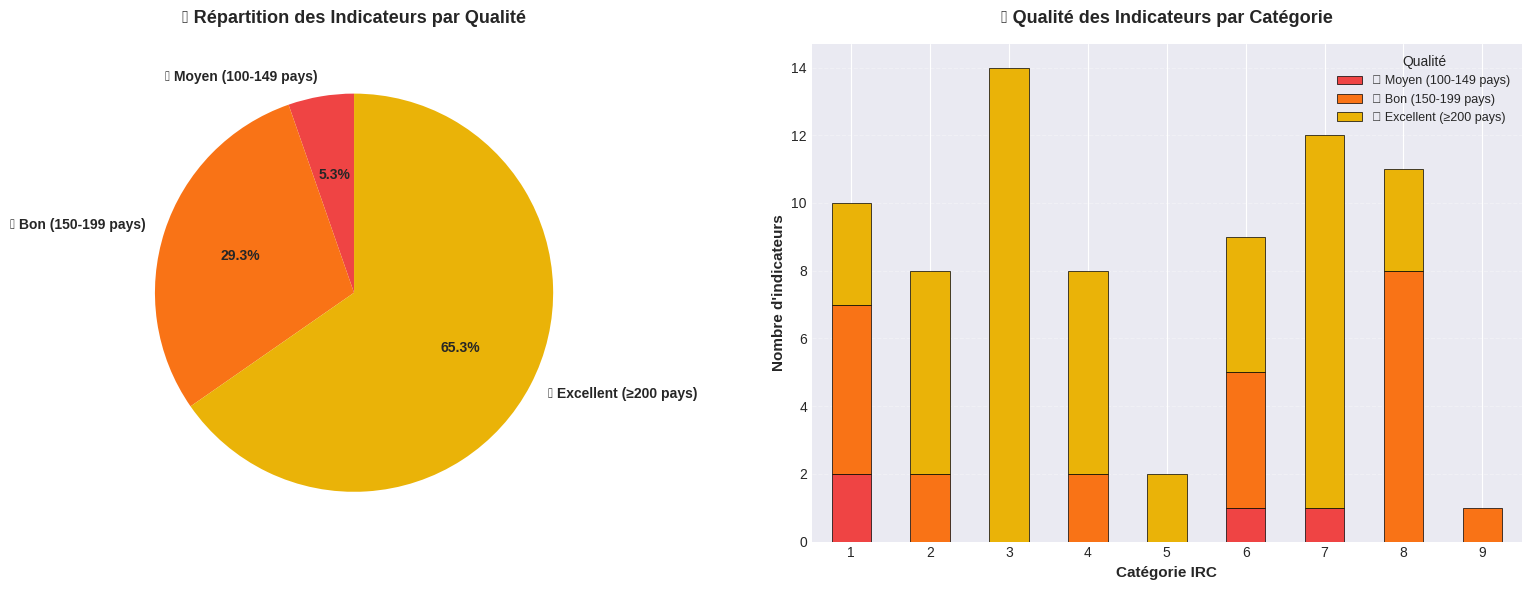

In [39]:
# Graphiques de qualité
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Pie chart - Répartition par qualité (palette inversée: vert=excellent, rouge=faible)
colors_quality = ['#ef4444', '#f97316', '#eab308', '#22c55e']  # Inversé: rouge→vert
ax1.pie(quality_stats.values, labels=quality_stats.index, autopct='%1.1f%%',
       colors=colors_quality, startangle=90, textprops={'fontsize': 10, 'fontweight': 'bold'})
ax1.set_title('📊 Répartition des Indicateurs par Qualité', 
             fontsize=13, fontweight='bold', pad=15)

# Bar chart - Nombre d'indicateurs par catégorie et qualité
quality_by_cat = density_df.groupby(['category_id', 'quality']).size().unstack(fill_value=0)
quality_by_cat.plot(kind='bar', stacked=True, ax=ax2, 
                   color=colors_quality, edgecolor='black', linewidth=0.5)
ax2.set_xlabel('Catégorie IRC', fontsize=11, fontweight='bold')
ax2.set_ylabel('Nombre d\'indicateurs', fontsize=11, fontweight='bold')
ax2.set_title('📊 Qualité des Indicateurs par Catégorie', 
             fontsize=13, fontweight='bold', pad=15)
ax2.legend(title='Qualité', fontsize=9, title_fontsize=10)
ax2.grid(axis='y', alpha=0.3, linestyle='--')
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=0)

plt.tight_layout()
plt.show()

## 5️⃣ Densité Temporelle: Nombre de Valeurs par Indicateur

Visualisation de la densité totale des données (nombre de valeurs enregistrées).

/tmp/ipykernel_128171/2018262423.py:22: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from current font.
  plt.tight_layout()


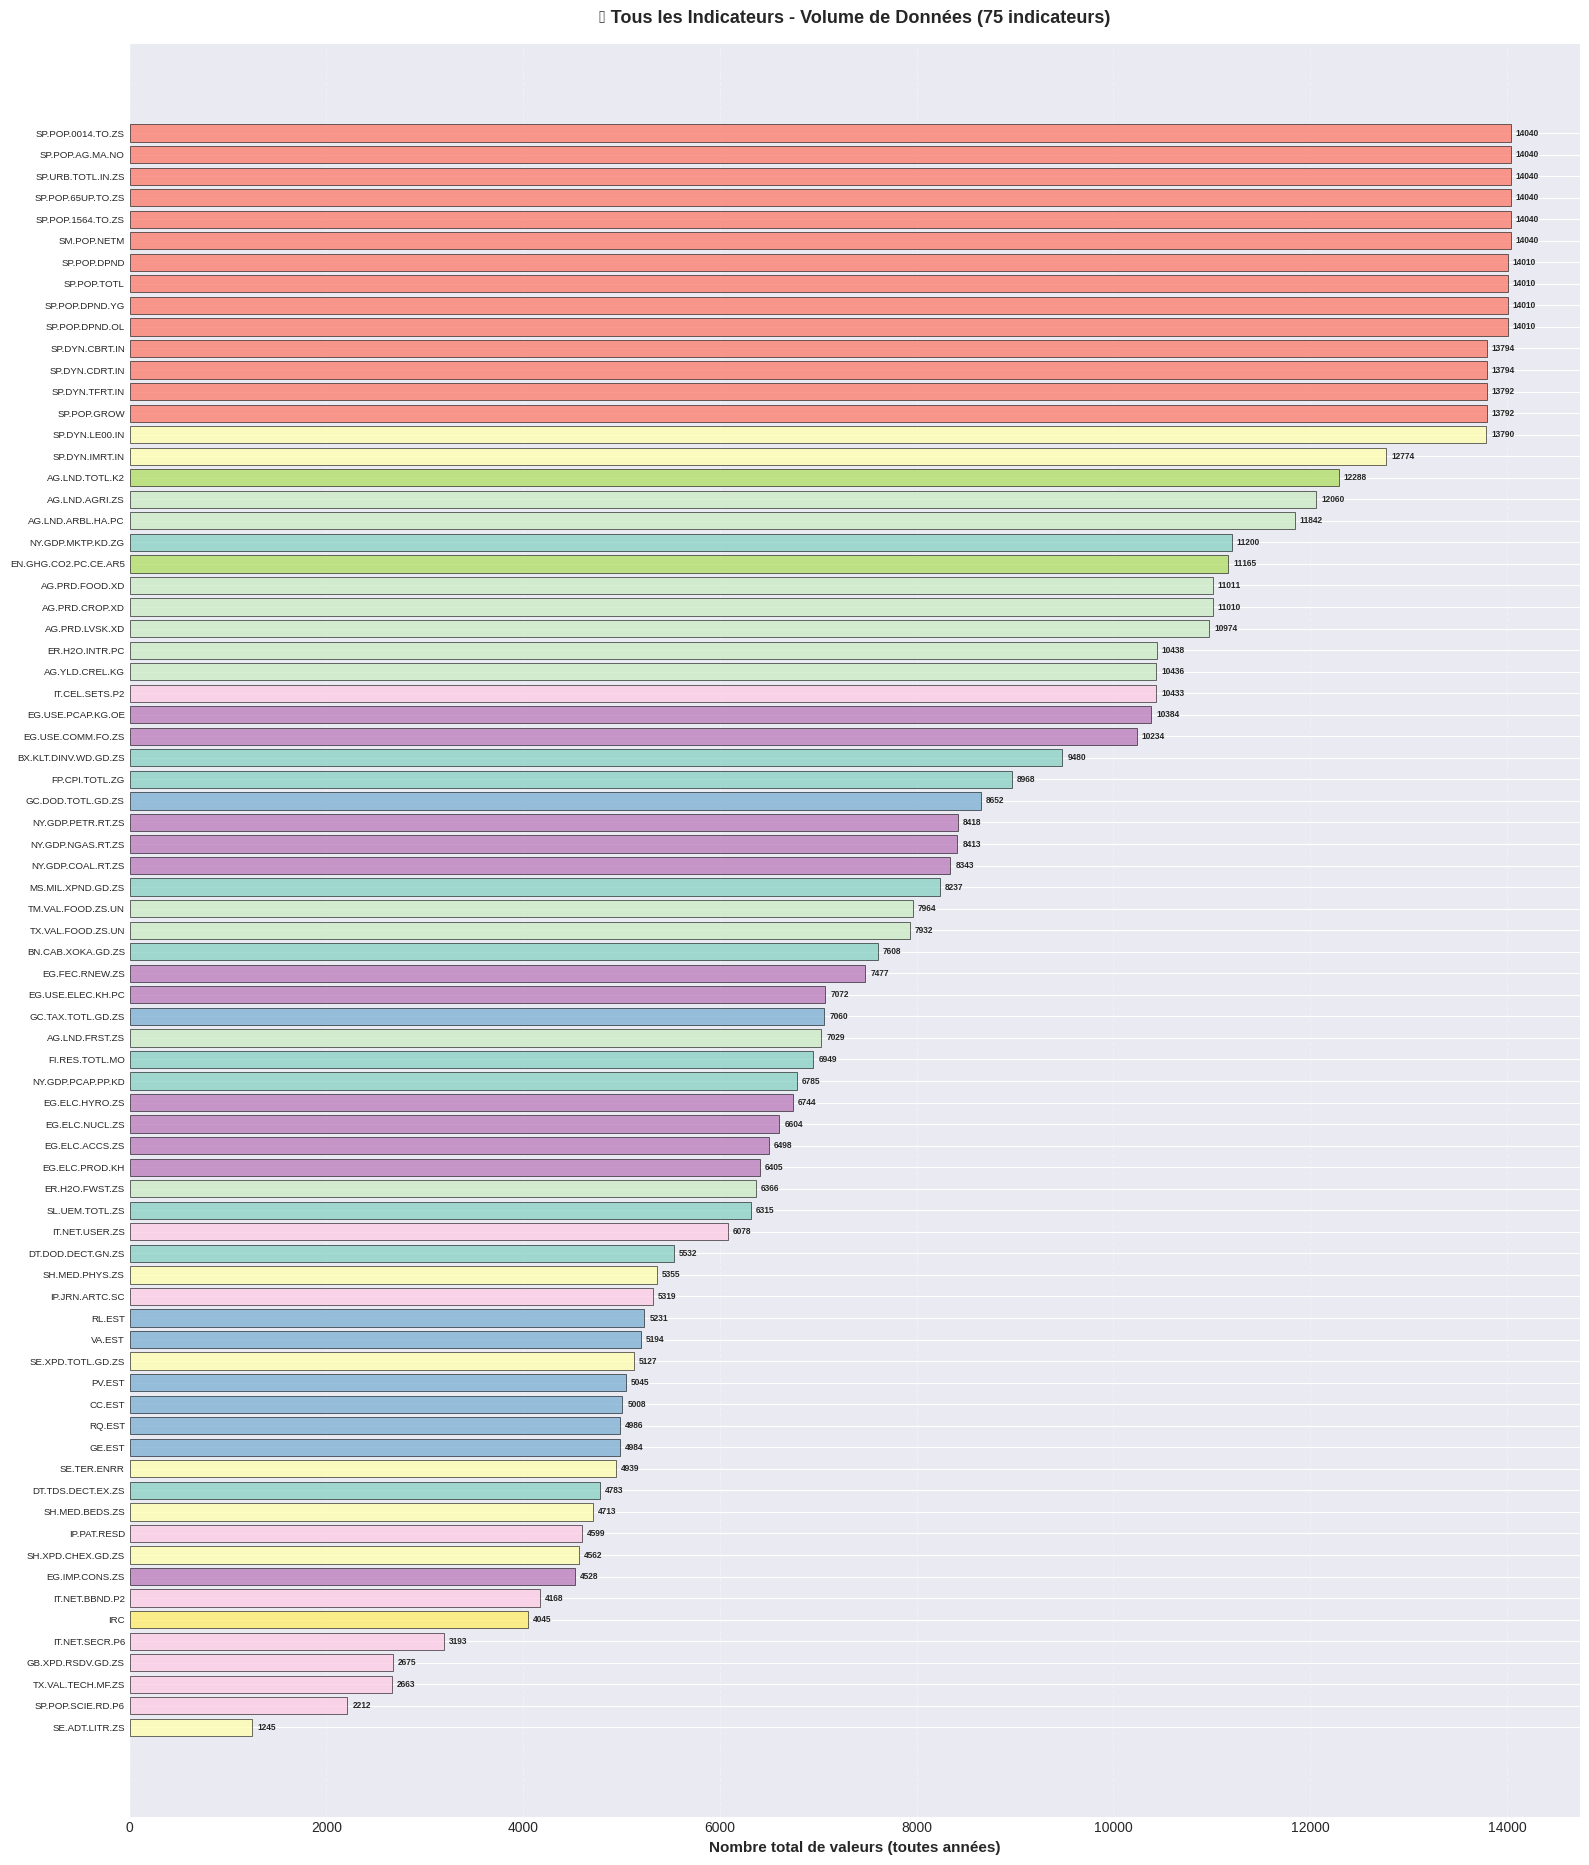


💾 Volume de données:
  • Total valeurs: 636,994
  • Moyenne par indicateur: 8493
  • Min: 1,245 (SE.ADT.LITR.ZS)
  • Max: 14,040 (SP.POP.1564.TO.ZS)


In [46]:
# Tous les indicateurs triés par volume de données (du plus faible au plus élevé)
all_indicators = density_df.sort_values('total_values', ascending=True)

fig, ax = plt.subplots(figsize=(16, max(12, len(all_indicators) * 0.25)))

bars = ax.barh(range(len(all_indicators)), all_indicators['total_values'],
              color=[color_map[cat] for cat in all_indicators['category_id']],
              edgecolor='black', linewidth=0.5, alpha=0.8)

ax.set_yticks(range(len(all_indicators)))
ax.set_yticklabels(all_indicators['code'], fontsize=7)
ax.set_xlabel('Nombre total de valeurs (toutes années)', fontsize=11, fontweight='bold')
ax.set_title(f'📊 Tous les Indicateurs - Volume de Données ({len(all_indicators)} indicateurs)', 
            fontsize=13, fontweight='bold', pad=15)
ax.grid(axis='x', alpha=0.3, linestyle='--')

# Ajouter les valeurs à la fin de chaque barre
for i, (idx, row) in enumerate(all_indicators.iterrows()):
    ax.text(row['total_values'] + 50, i, f"{row['total_values']:.0f}", 
           va='center', fontsize=6, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\n💾 Volume de données:")
print(f"  • Total valeurs: {density_df['total_values'].sum():,.0f}")
print(f"  • Moyenne par indicateur: {density_df['total_values'].mean():.0f}")
print(f"  • Min: {density_df['total_values'].min():,.0f} ({density_df.loc[density_df['total_values'].idxmin(), 'code']})")
print(f"  • Max: {density_df['total_values'].max():,.0f} ({density_df.loc[density_df['total_values'].idxmax(), 'code']})")

## 6️⃣ Boxplot: Distribution par Catégorie

Comparaison des distributions de couverture entre les catégories IRC.

/tmp/ipykernel_128171/813990637.py:24: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from current font.
  plt.tight_layout()
/home/elias/anaconda3/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


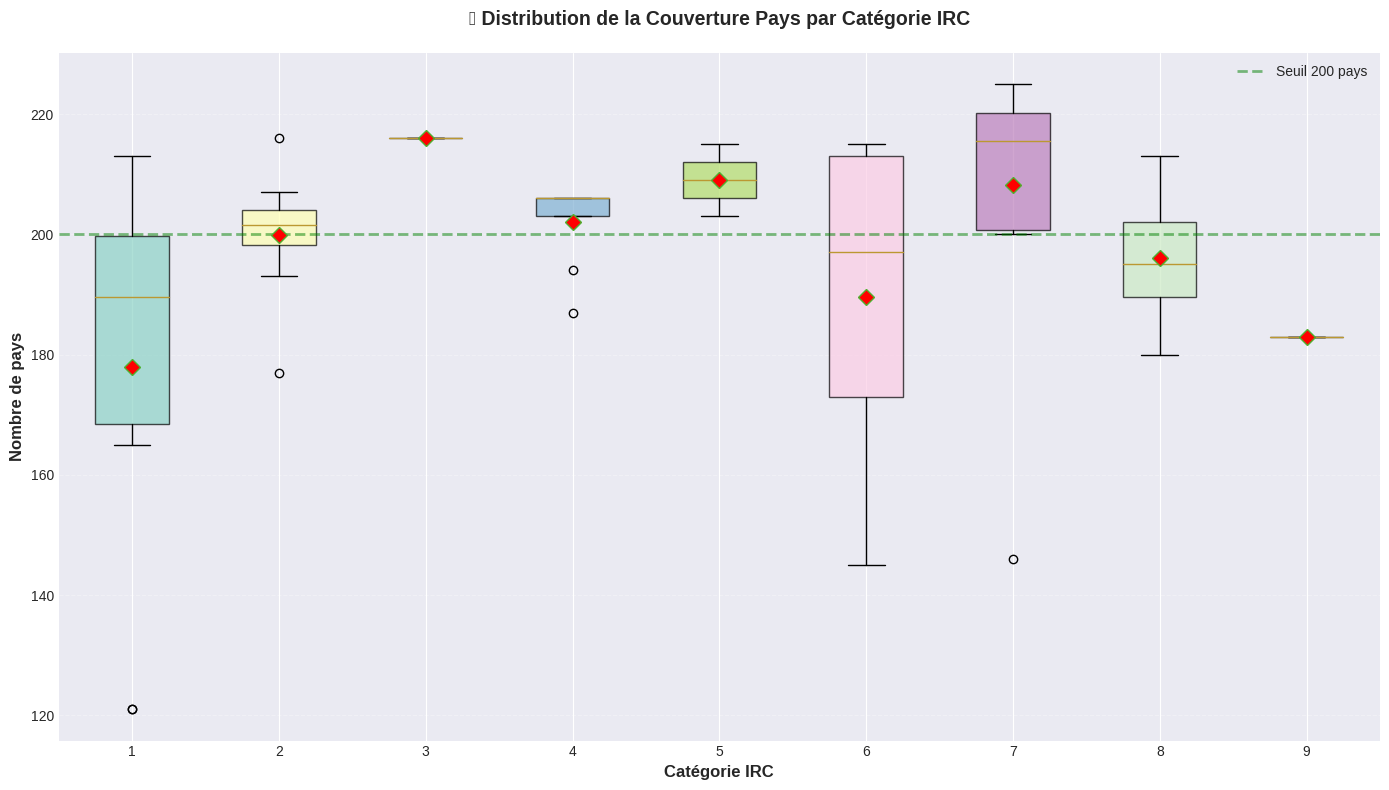

In [41]:
fig, ax = plt.subplots(figsize=(14, 8))

# Créer le boxplot
box_data = [density_df[density_df['category_id'] == cat]['country_count'].values 
            for cat in sorted(density_df['category_id'].unique())]

bp = ax.boxplot(box_data, labels=sorted(density_df['category_id'].unique()),
               patch_artist=True, showmeans=True,
               meanprops=dict(marker='D', markerfacecolor='red', markersize=8))

# Colorier les boxes
for patch, cat in zip(bp['boxes'], sorted(density_df['category_id'].unique())):
    patch.set_facecolor(color_map[cat])
    patch.set_alpha(0.7)

ax.set_xlabel('Catégorie IRC', fontsize=12, fontweight='bold')
ax.set_ylabel('Nombre de pays', fontsize=12, fontweight='bold')
ax.set_title('📦 Distribution de la Couverture Pays par Catégorie IRC', 
            fontsize=14, fontweight='bold', pad=20)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.axhline(y=200, color='green', linestyle='--', linewidth=2, alpha=0.5, label='Seuil 200 pays')
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

## 📊 Résumé Exécutif

Tableau récapitulatif des statistiques clés.

In [42]:
# Créer un rapport récapitulatif
summary_report = f"""
╔═══════════════════════════════════════════════════════════════════╗
║                                                                   ║
║           📊 RAPPORT IRC - COUVERTURE INDICATEURS                 ║
║                   28 février 2026                                 ║
║                                                                   ║
╚═══════════════════════════════════════════════════════════════════╝

📈 STATISTIQUES GLOBALES
═══════════════════════════════════════════════════════════════════
  • Nombre total d'indicateurs : {len(density_df)}
  • Nombre total de valeurs : {density_df['total_values'].sum():,.0f}
  • Période couverte : {temporal_df['first_year'].min():.0f} - {temporal_df['last_year'].max():.0f}
  • Durée moyenne : {(temporal_df['last_year'] - temporal_df['first_year']).mean():.1f} ans

🌍 COUVERTURE PAYS
═══════════════════════════════════════════════════════════════════
  • Moyenne par indicateur : {density_df['country_count'].mean():.1f} pays
  • Médiane : {density_df['country_count'].median():.1f} pays
  • Maximum : {density_df['country_count'].max():.0f} pays ({density_df.loc[density_df['country_count'].idxmax(), 'code']})
  • Minimum : {density_df['country_count'].min():.0f} pays ({density_df.loc[density_df['country_count'].idxmin(), 'code']})

🎯 QUALITÉ DE COUVERTURE
═══════════════════════════════════════════════════════════════════
  {quality_stats.to_string()}

💾 VOLUME DE DONNÉES
═══════════════════════════════════════════════════════════════════
  • Moyenne valeurs/indicateur : {density_df['total_values'].mean():.0f}
  • Médiane : {density_df['total_values'].median():.0f}
  • Indicateur le plus dense : {density_df.loc[density_df['total_values'].idxmax(), 'code']} ({density_df['total_values'].max():,.0f} valeurs)

═══════════════════════════════════════════════════════════════════
"""

print(summary_report)


╔═══════════════════════════════════════════════════════════════════╗
║                                                                   ║
║           📊 RAPPORT IRC - COUVERTURE INDICATEURS                 ║
║                   28 février 2026                                 ║
║                                                                   ║
╚═══════════════════════════════════════════════════════════════════╝

📈 STATISTIQUES GLOBALES
═══════════════════════════════════════════════════════════════════
  • Nombre total d'indicateurs : 75
  • Nombre total de valeurs : 636,994
  • Période couverte : 1950 - 2025
  • Durée moyenne : 51.5 ans

🌍 COUVERTURE PAYS
═══════════════════════════════════════════════════════════════════
  • Moyenne par indicateur : 199.7 pays
  • Médiane : 206.0 pays
  • Maximum : 225 pays (EG.FEC.RNEW.ZS)
  • Minimum : 121 pays (DT.DOD.DECT.GN.ZS)

🎯 QUALITÉ DE COUVERTURE
═══════════════════════════════════════════════════════════════════
  🟠 Moyen (100-149 pa

In [43]:
# Fermer la connexion
conn.close()
print("\n✅ Connexion fermée")


✅ Connexion fermée
